In [29]:
# 解决matplotlib中文显示乱码问题
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.font_manager import FontProperties
import platform

# 设置中文字体
def setup_chinese_font():
    """设置matplotlib中文字体"""
    system = platform.system()
    
    if system == "Windows":
        # Windows系统常用中文字体
        font_candidates = ['SimHei', 'Microsoft YaHei', 'KaiTi', 'FangSong']
    elif system == "Darwin":  # macOS
        font_candidates = ['Arial Unicode MS', 'Heiti TC', 'PingFang SC']
    else:  # Linux
        font_candidates = ['WenQuanYi Micro Hei', 'DejaVu Sans']
    
    for font_name in font_candidates:
        try:
            # 测试字体是否可用
            plt.rcParams['font.sans-serif'] = [font_name]
            plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题
            
            # 测试绘图
            fig, ax = plt.subplots(figsize=(1, 1))
            ax.text(0.5, 0.5, '测试中文', fontsize=12, ha='center')
            plt.close(fig)
            
            print(f"成功设置中文字体: {font_name}")
            return True
        except:
            continue
    
    print("警告: 未找到合适的中文字体，可能仍会出现乱码")
    return False

# 运行字体设置
setup_chinese_font()

# 显示当前字体设置
print(f"当前字体设置: {plt.rcParams['font.sans-serif']}")
print(f"负号显示设置: {plt.rcParams['axes.unicode_minus']}")


成功设置中文字体: SimHei
当前字体设置: ['SimHei']
负号显示设置: False


### T1


In [30]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.stats import norm

# --- 参数定义 ---
# 正态分布参数 (矩形中心点)
mean = 0
std_dev = 120

# 矩形尺寸
rect_length = 100  # 沿 X 轴
rect_width = 20   # 沿 Y 轴
half_length = rect_length / 2
half_width = rect_width / 2

# --- 数据准备 ---
# 创建 x 和 y 轴的坐标点. 范围需要足够大以包含矩形和分布的大部分区域
# 我们选择 -600 到 600, 大约是 5 倍的标准差
x = np.linspace(-600, 600, 400)
y = np.linspace(-600, 600, 400)
X, Y = np.meshgrid(x, y)

# --- 计算覆盖概率 ---
# 对于平面上的每个点 (x, y), 我们计算它被矩形覆盖的概率。
# 这等于矩形中心 (Xc, Yc) 落在 [x-L/2, x+L/2] x [y-W/2, y+W/2] 区域的概率。

# 创建一个标准差为 std_dev, 均值为 mean 的一维正态分布对象
rv_norm = norm(loc=mean, scale=std_dev)

# 计算 x 和 y 方向上的累积概率差
# P(X - L/2 < Xc < X + L/2)
prob_x = rv_norm.cdf(X + half_length) - rv_norm.cdf(X - half_length)
# P(Y - W/2 < Yc < Y + W/2)
prob_y = rv_norm.cdf(Y + half_width) - rv_norm.cdf(Y - half_width)

# 因为 Xc 和 Yc 是独立的, 总概率是两个方向概率的乘积
Z = prob_x * prob_y

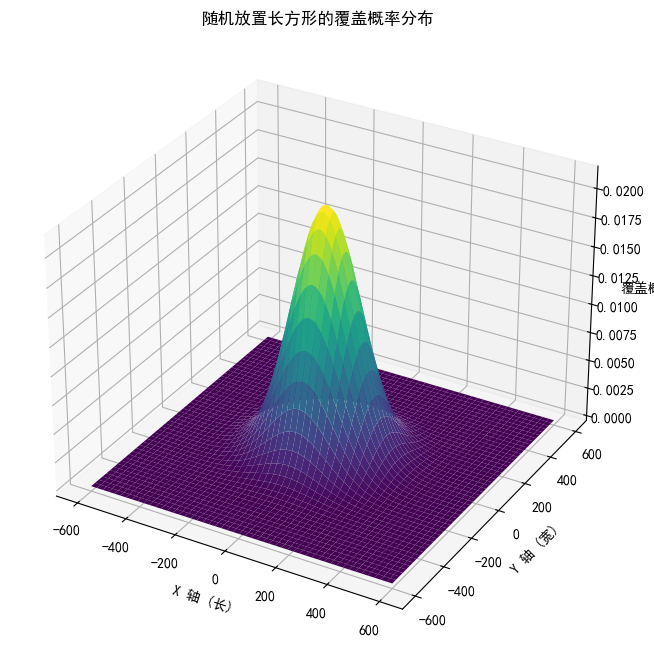

In [31]:
# --- 绘制3D图像 ---
# 创建一个图形实例
fig = plt.figure(figsize=(12, 8))
# 在图形中添加一个3D坐标轴
ax = fig.add_subplot(111, projection='3d')

# 绘制3D曲面图
ax.plot_surface(X, Y, Z, cmap='viridis')

# --- 设置坐标轴和标题 ---
ax.set_xlabel('X 轴 (长)')
ax.set_ylabel('Y 轴 (宽)')
ax.set_zlabel('覆盖概率')
ax.set_title('随机放置长方形的覆盖概率分布')

# --- 显示图像 ---
plt.show() 

### T2


In [ ]:
import numpy as np
from scipy.stats import truncnorm
import matplotlib.pyplot as plt

# h0: 潜艇中心位置深度的定位值 (原始分布的均值)
h0 = 150 
# sigma_z: Z方向的标准差
sigma_z = 40 
# l: 潜艇中心位置实际深度的最小值 (截断点)
l = 120  

# --- 2. 创建单边截尾正态分布对象 ---
# 计算 scipy.stats.truncnorm 所需的标准化截断边界 (a, b)
# 下边界是 l，上边界是无穷大
a = (l - h0) / sigma_z
b = np.inf

# 创建代表潜艇深度 Zc 分布的截尾正态分布对象
# Zc ~ N(h0, sigma_z^2) for Zc > l
rv_trunc = truncnorm(a=a, b=b, loc=h0, scale=sigma_z)

# --- 3. 绘制 Z 的概率密度函数图 ---
# 创建 Z 轴的坐标点
z_values = np.linspace(80, 300, 1000)
# 计算概率密度函数值
pdf_z = rv_trunc.pdf(z_values)

# 绘制概率密度函数图
plt.figure(figsize=(10, 6))
plt.plot(z_values, pdf_z, 'b-', linewidth=2, label='Z的概率密度函数')
plt.axvline(x=l, color='r', linestyle='--', label=f'截断点 l={l}')
plt.axvline(x=h0, color='g', linestyle='--', label=f'原均值 h0={h0}')
plt.xlabel('Z值（深度）')
plt.ylabel('概率密度')
plt.title('潜艇深度 Z 的截尾正态分布概率密度函数')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Z轴范围: {z_values.min():.1f} 到 {z_values.max():.1f}")
print(f"Z方向概率密度函数最大值: {pdf_z.max():.4f}")
print(f"Z方向概率密度函数在原均值处的值: {rv_trunc.pdf(h0):.4f}")

In [34]:
# # --- 4. 计算三维空间概率密度函数 ---
# # 长方体在Z方向的尺寸
# H = 25     
# half_depth = H / 2

# # 创建三维坐标轴
# # 重新定义z轴坐标点（与x，y保持一致的网格密度）
# z = np.linspace(80, 300, 100)  # Z轴范围，减少点数以节省计算时间
# # 使用更少的点来创建三维网格
# x_3d = np.linspace(-600, 600, 100)
# y_3d = np.linspace(-600, 600, 100)
# X_3d, Y_3d = np.meshgrid(x_3d, y_3d)

# # 重新计算X和Y方向的概率密度
# rv_norm = norm(loc=mean, scale=std_dev)
# prob_x_3d = rv_norm.cdf(X_3d + half_length) - rv_norm.cdf(X_3d - half_length)
# prob_y_3d = rv_norm.cdf(Y_3d + half_width) - rv_norm.cdf(Y_3d - half_width)

# # 计算XY平面的概率密度
# prob_xy = prob_x_3d * prob_y_3d

# # 计算三维空间概率密度函数
# # 为了可视化，我们选择几个特定的Z值
# z_selected = [120, 150, 180, 220]  # 选择几个有代表性的Z值
# prob_xyz_dict = {}

# for z_val in z_selected:
#     # 计算在该Z值处的概率密度
#     prob_z_val = rv_trunc.cdf(z_val + half_depth) - rv_trunc.cdf(z_val - half_depth)
    
#     # 计算三维空间概率密度函数
#     prob_xyz = prob_xy * prob_z_val
#     prob_xyz_dict[z_val] = prob_xyz
    
#     print(f"Z = {z_val} 处的概率密度最大值: {prob_xyz.max():.6f}")

# # 绘制不同Z值处的XY平面概率密度分布
# fig, axes = plt.subplots(2, 2, figsize=(15, 12))
# fig.suptitle('不同深度Z处的XY平面概率密度分布', fontsize=16)

# for i, z_val in enumerate(z_selected):
#     row = i // 2
#     col = i % 2
#     ax = axes[row, col]
    
#     # 绘制等高线图
#     contour = ax.contourf(X_3d, Y_3d, prob_xyz_dict[z_val], levels=20, cmap='viridis')
#     ax.set_xlabel('X轴')
#     ax.set_ylabel('Y轴')
#     ax.set_title(f'Z = {z_val}m 处的概率密度')
#     plt.colorbar(contour, ax=ax)

# plt.tight_layout()
# # plt.show()

# # # 计算并显示一些统计信息
# # print("\n=== 三维空间概率密度函数统计信息 ===")
# # print(f"长方体尺寸: {rect_length} × {rect_width} × {H}")
# # print(f"X,Y分布参数: 均值={mean}, 标准差={std_dev}")
# # print(f"Z分布参数: 均值={h0}, 标准差={sigma_z}, 截断点={l}")
# # print(f"概率密度函数: prob_xyz = prob_x × prob_y × prob_z")
# # print(f"其中 prob_x × prob_y 的最大值: {prob_xy.max():.6f}")

# # for z_val in z_selected:
# #     prob_z_val = rv_trunc.cdf(z_val + half_depth) - rv_trunc.cdf(z_val - half_depth)
# #     print(f"Z = {z_val} 处的 prob_z: {prob_z_val:.6f}")


In [ ]:
# --- 5. 三维可视化 ---
from mpl_toolkits.mplot3d import Axes3D

# 创建一个更粗糙的三维网格用于3D可视化（减少计算量）
x_coarse = np.linspace(-400, 400, 30)
y_coarse = np.linspace(-400, 400, 30)
z_coarse = np.linspace(100, 250, 20)
X_coarse, Y_coarse, Z_coarse = np.meshgrid(x_coarse, y_coarse, z_coarse)

# 计算三维概率密度函数
rv_norm = norm(loc=mean, scale=std_dev)
prob_x_coarse = rv_norm.cdf(X_coarse + half_length) - rv_norm.cdf(X_coarse - half_length)
prob_y_coarse = rv_norm.cdf(Y_coarse + half_width) - rv_norm.cdf(Y_coarse - half_width)

# 计算Z方向的概率密度
prob_z_coarse = rv_trunc.cdf(Z_coarse + half_depth) - rv_trunc.cdf(Z_coarse - half_depth)

# 计算完整的三维概率密度函数
prob_xyz_3d = prob_x_coarse * prob_y_coarse * prob_z_coarse

# 创建增强的三维散点图，所有属性都与概率密度相关
fig = plt.figure(figsize=(15, 10))
ax = fig.add_subplot(111, projection='3d')

# 1. 智能采样：根据概率密度决定散点数量和分布
# 首先将所有点按概率密度排序，然后分层采样
all_points = np.column_stack([X_coarse.flatten(), Y_coarse.flatten(), Z_coarse.flatten(), prob_xyz_3d.flatten()])
# 按概率密度排序（从小到大）
sorted_indices = np.argsort(all_points[:, 3])
sorted_points = all_points[sorted_indices]

# 设置基本阈值，只保留有意义的点
base_threshold = 0.0001
valid_mask = sorted_points[:, 3] > base_threshold
valid_points = sorted_points[valid_mask]

# 根据概率密度值分层采样
n_total_samples = 1500  # 总采样数量
prob_values = valid_points[:, 3]

# 使用概率密度值作为权重进行采样
# 概率密度越高，被选中的可能性越大
weights = prob_values / np.sum(prob_values)
sample_indices = np.random.choice(len(valid_points), size=n_total_samples, 
                                 replace=False, p=weights)

# 获取采样后的点
sampled_points = valid_points[sample_indices]
x_plot = sampled_points[:, 0]
y_plot = sampled_points[:, 1]
z_plot = sampled_points[:, 2]
c_plot = sampled_points[:, 3]

# 2. 计算散点大小：与概率密度成比例
# 将概率密度值映射到合适的大小范围
min_size = 10
max_size = 200
c_normalized = (c_plot - c_plot.min()) / (c_plot.max() - c_plot.min())
sizes = min_size + (max_size - min_size) * c_normalized

# 3. 计算透明度：与概率密度成比例
# 将概率密度值映射到透明度范围
min_alpha = 0.1
max_alpha = 0.9
alphas = min_alpha + (max_alpha - min_alpha) * c_normalized

# 4. 绘制散点图，所有属性都与概率密度相关
# 解决方案：将透明度信息编码到颜色的 RGBA 值中
from matplotlib.colors import to_rgba_array
import matplotlib.pyplot as plt

# 首先将概率密度值映射到colormap
cmap = plt.cm.viridis
norm = plt.Normalize(vmin=c_plot.min(), vmax=c_plot.max())
colors = cmap(norm(c_plot))

# 将透明度信息设置到颜色的 alpha 通道中
colors[:, 3] = alphas  # 设置 alpha 通道

scatter = ax.scatter(x_plot, y_plot, z_plot, 
                    c=colors,          # 使用包含透明度的颜色
                    s=sizes,           # 大小与概率密度相关
                    edgecolors='none')

ax.set_xlabel('X轴')
ax.set_ylabel('Y轴')
ax.set_zlabel('Z轴（深度）')
ax.set_title('三维空间概率密度分布\n(散点大小、透明度、颜色都与概率密度相关)')

# 创建 colorbar，使用 ScalarMappable 对象
from matplotlib.cm import ScalarMappable
sm = ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
plt.colorbar(sm, ax=ax, label='概率密度', shrink=0.8)
plt.show()

# 打印统计信息
print(f"=== 增强散点图统计信息 ===")
print(f"总散点数量: {len(x_plot)}")
print(f"概率密度范围: {c_plot.min():.8f} - {c_plot.max():.8f}")
print(f"散点大小范围: {sizes.min():.1f} - {sizes.max():.1f}")
print(f"透明度范围: {alphas.min():.2f} - {alphas.max():.2f}")

# 分析散点的分布
print(f"\n=== 散点分布分析 ===")
print(f"原始网格点总数: {prob_xyz_3d.size}")
print(f"有效点数 (概率密度 > {base_threshold}): {len(valid_points)}")
print(f"采样率: {len(x_plot)/len(valid_points):.2%}")

# 概率密度分位数统计
percentiles = [50, 75, 90, 95, 99]
print(f"\n=== 概率密度分位数 ===")
for p in percentiles:
    value = np.percentile(c_plot, p)
    count = np.sum(c_plot >= value)
    print(f"{p}分位数: {value:.6f} (包含 {count} 个散点, 占比 {count/len(c_plot):.1%})")

# 空间分布统计
print(f"\n=== 空间分布范围 ===")
print(f"X轴范围: {x_plot.min():.1f} - {x_plot.max():.1f}")
print(f"Y轴范围: {y_plot.min():.1f} - {y_plot.max():.1f}")  
print(f"Z轴范围: {z_plot.min():.1f} - {z_plot.max():.1f}")

print(f"\n=== 可视化技术说明 ===")
print("✓ 散点数量：基于概率密度加权采样，高密度区域散点更多")
print("✓ 散点大小：与概率密度成正比，范围 {:.0f}-{:.0f}".format(min_size, max_size))
print("✓ 散点颜色：使用viridis色彩映射，表示概率密度值")
print("✓ 散点透明度：与概率密度成正比，通过RGBA颜色编码实现")
print("✓ 解决了matplotlib 3D散点图中颜色与透明度冲突的问题")
